In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from PIL import Image
import random

In [11]:
def rbf_kernel(X, Y, gamma):
    """Compute RBF (Gaussian) kernel matrix between X and Y."""
    X_sq = np.sum(X ** 2, axis=1).reshape(-1, 1)
    Y_sq = np.sum(Y ** 2, axis=1).reshape(1, -1)
    dist_sq = X_sq + Y_sq - 2 * X @ Y.T
    return np.exp(-gamma * dist_sq)

### Load Yale Faces Dataset

Number of persons: 15

n_train = 4, n_test = 1 (selected from remaining 7)
Training set: 60 images
Test set: 15 images
Feature dimension: 77760
Image size: (243, 320)
Training matrix: (60, 77760), Test matrix: (15, 77760)


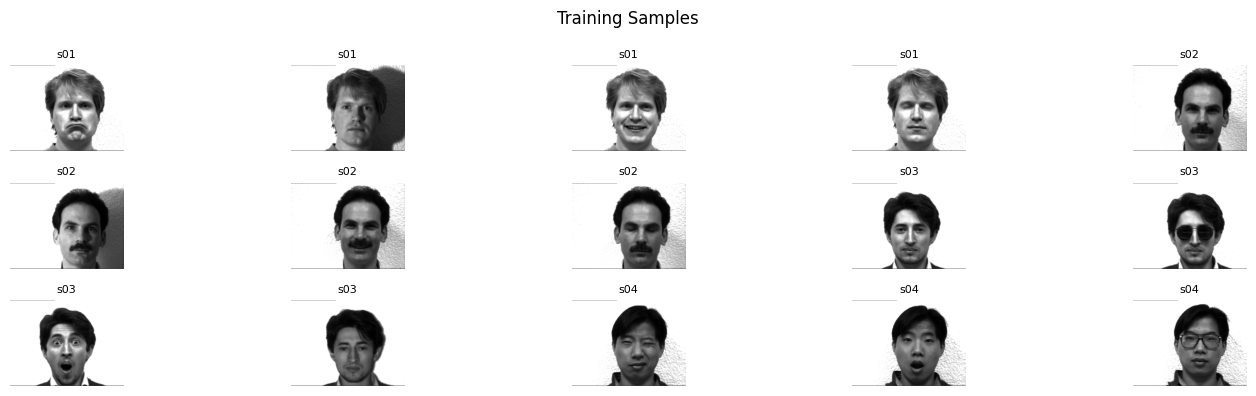

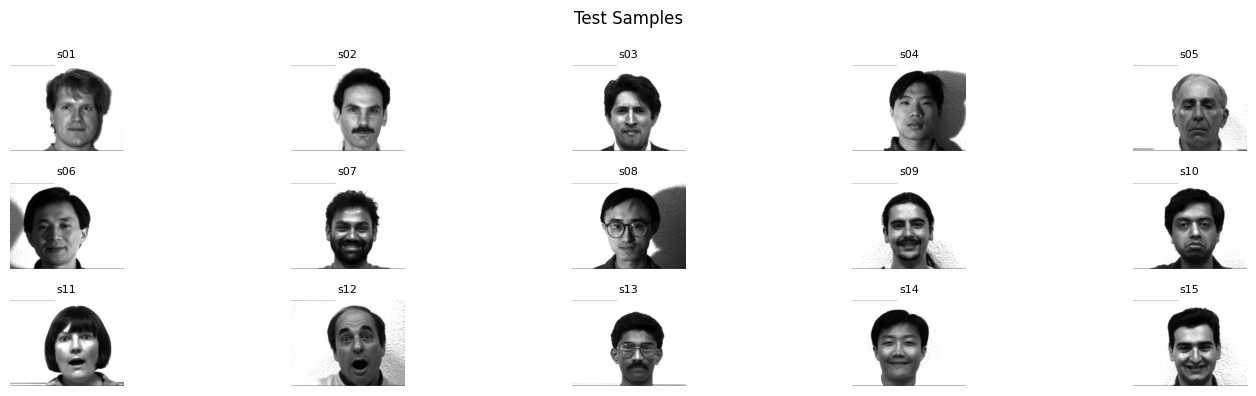

In [12]:
def load_yale_faces(path):
    """Load all Yale faces, grouped by person"""
    persons = {}
    for folder in sorted(os.listdir(path)):
        folder_path = os.path.join(path, folder)
        if os.path.isdir(folder_path):
            imgs = []
            for f in sorted(os.listdir(folder_path)):
                filepath = os.path.join(folder_path, f)
                if os.path.isfile(filepath):
                    try:
                        img = Image.open(filepath)
                        imgs.append(np.array(img, dtype=np.float64))
                    except Exception:
                        pass
            if imgs:
                persons[folder] = imgs
    return persons

def split_data(persons, n_train, seed=42):
    """
    Split data: randomly select n_train images for training per person,
    then randomly select 1 image from the remaining as test.
    """
    random.seed(seed)
    train_imgs, train_labels = [], []
    test_imgs, test_labels = [], []

    for label, imgs in persons.items():
        if len(imgs) <= n_train:
            raise ValueError(
                f"Person '{label}' has only {len(imgs)} images, "
                f"need at least {n_train + 1} (n_train={n_train} + 1 for test)."
            )
        indices = list(range(len(imgs)))
        random.shuffle(indices)

        # First n_train shuffled indices -> training
        train_indices = indices[:n_train]
        # From remaining, randomly pick 1 -> test
        remaining = indices[n_train:]
        test_index = random.choice(remaining)

        for i in train_indices:
            train_imgs.append(imgs[i])
            train_labels.append(label)

        test_imgs.append(imgs[test_index])
        test_labels.append(label)

    return train_imgs, train_labels, test_imgs, test_labels

# Load data
persons = load_yale_faces("Datasets/yalefaces")
print(f"Number of persons: {len(persons)}")
# for label, imgs in persons.items():
#    print(f"  {label}: {len(imgs)} images, size {imgs[0].shape}")

n_train = 4  # number of training images per person

train_imgs, train_labels, test_imgs, test_labels = split_data(persons, n_train=n_train)

X_train = np.array([img.flatten() for img in train_imgs])
X_test = np.array([img.flatten() for img in test_imgs])
y_train = np.array(train_labels)
y_test = np.array(test_labels)

n_imgs_per_person = len(next(iter(persons.values())))
print(f"\nn_train = {n_train}, n_test = 1 (selected from remaining {n_imgs_per_person - n_train})")
print(f"Training set: {X_train.shape[0]} images")
print(f"Test set: {X_test.shape[0]} images")
print(f"Feature dimension: {X_train.shape[1]}")

print(f"Image size: {train_imgs[0].shape}")
print(f"Training matrix: {X_train.shape}, Test matrix: {X_test.shape}")

# Visualize some training samples
fig, axes = plt.subplots(3, 5, figsize=(15, 4))
for i, ax in enumerate(axes.flatten()):
    if i < len(train_imgs):
        ax.imshow(train_imgs[i], cmap='gray')
        ax.set_title(f"{train_labels[i]}", fontsize=8)
    ax.axis('off')
plt.suptitle("Training Samples")
plt.tight_layout()
plt.show()

# Visualize some test samples
fig, axes = plt.subplots(3, 5, figsize=(15, 4))
for i, ax in enumerate(axes.flatten()):
    if i < len(test_imgs):
        ax.imshow(test_imgs[i], cmap='gray')
        ax.set_title(f"{test_labels[i]}", fontsize=8)
    ax.axis('off')
plt.suptitle("Test Samples")
plt.tight_layout()
plt.show()

### Training Kernel Matrix 

In [13]:
gamma = 1e-9

K_train = rbf_kernel(X_train, X_train, gamma)

print(f"Training kernel matrix shape: {K_train.shape}")

Training kernel matrix shape: (60, 60)


###  Center the Kernel Matrix

Centered kernel matrix shape: (60, 60)
Row mean (should ≈ 0): 3.53e-16


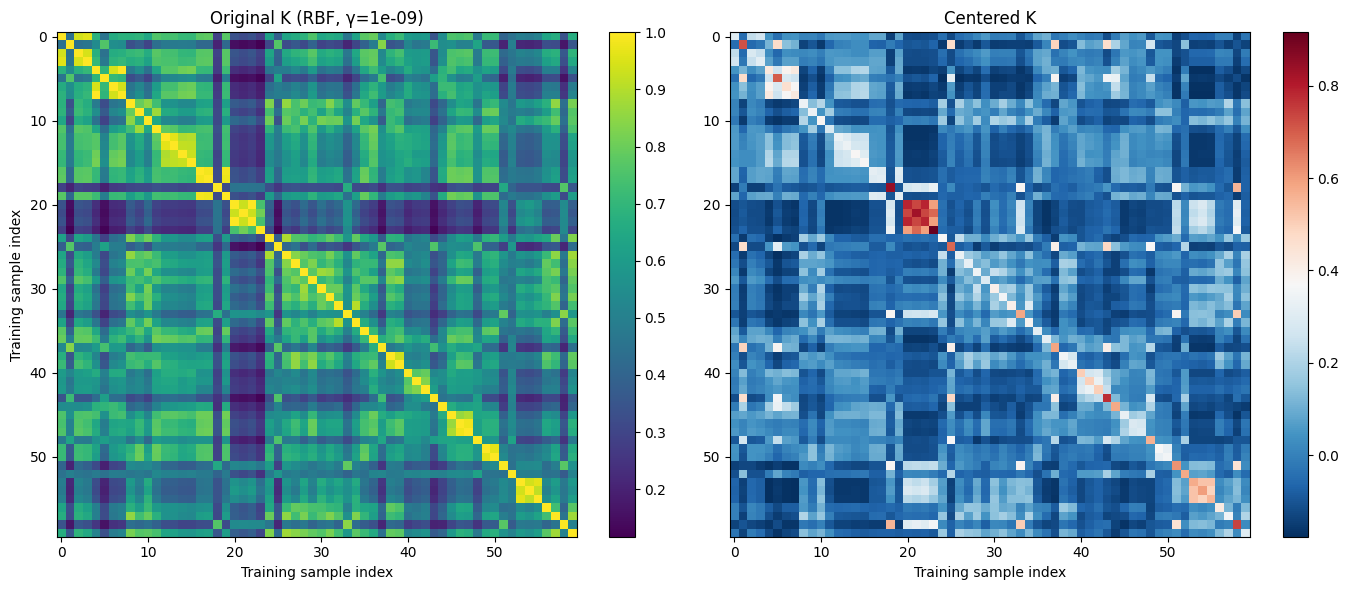

In [14]:
# K_c = K - 1_N K - K 1_N + 1_N K 1_N
N = K_train.shape[0]
one_N = np.ones((N, N)) / N

K_centered = K_train - one_N @ K_train - K_train @ one_N + one_N @ K_train @ one_N

print(f"Centered kernel matrix shape: {K_centered.shape}")
print(f"Row mean (should ≈ 0): {np.abs(K_centered.mean(axis=1)).max():.2e}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(K_train, cmap='viridis', aspect='auto')
axes[0].set_title(f"Original K (RBF, γ={gamma})")
axes[0].set_xlabel("Training sample index")
axes[0].set_ylabel("Training sample index")
plt.colorbar(axes[0].images[0], ax=axes[0])

axes[1].imshow(K_centered, cmap='RdBu_r', aspect='auto')
axes[1].set_title("Centered K")
axes[1].set_xlabel("Training sample index")
plt.colorbar(axes[1].images[0], ax=axes[1])

plt.tight_layout()
plt.show()

### Eigendecomposition and Normalization

Number of positive eigenvalues: 58 / 60
Top 10 eigenvalues: [5.89922317 4.06629651 2.24963132 1.59107871 1.2728876  1.19466868
 1.05668369 0.92870675 0.81210641 0.73667187]
alphas shape: (60, 58)


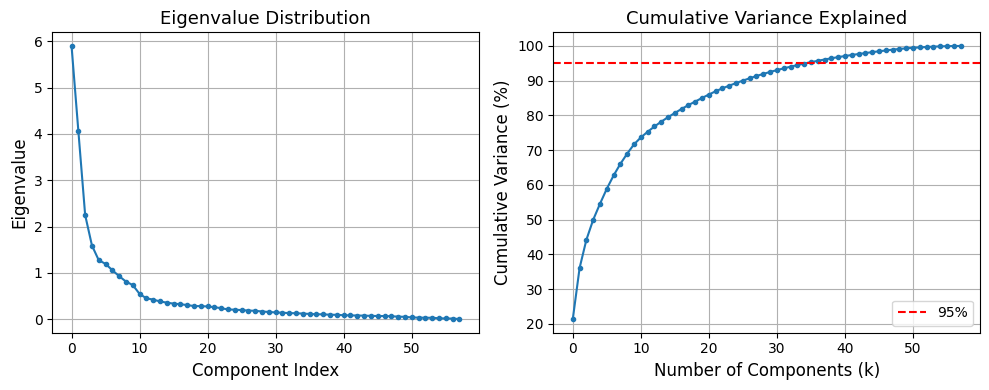


Components needed to reach 95% cumulative variance: 36


In [15]:
eigenvalues, eigenvectors = np.linalg.eigh(K_centered)

# Sort by descending eigenvalue
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Keep only positive eigenvalues (discard numerical noise)
pos_mask = eigenvalues > 1e-10
eigenvalues = eigenvalues[pos_mask]
eigenvectors = eigenvectors[:, pos_mask]

print(f"Number of positive eigenvalues: {len(eigenvalues)} / {K_centered.shape[0]}")
print(f"Top 10 eigenvalues: {eigenvalues[:10]}")

# Normalize: alpha^(m) = eigenvector^(m) / sqrt(lambda_m)
alphas = eigenvectors / np.sqrt(eigenvalues)

print(f"alphas shape: {alphas.shape}")

# ====================================================================
# Visualize Eigenvalue Distribution
# ====================================================================
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(eigenvalues, marker='o', markersize=3)
plt.xlabel("Component Index", fontsize=12)
plt.ylabel("Eigenvalue", fontsize=12)
plt.title("Eigenvalue Distribution", fontsize=13)
plt.grid(True)

cumulative_ratio = np.cumsum(eigenvalues) / np.sum(eigenvalues) * 100
plt.subplot(1, 2, 2)
plt.plot(cumulative_ratio, marker='o', markersize=3)
plt.xlabel("Number of Components (k)", fontsize=12)
plt.ylabel("Cumulative Variance (%)", fontsize=12)
plt.title("Cumulative Variance Explained", fontsize=13)
plt.axhline(y=95, color='r', linestyle='--', label='95%')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

k_95 = np.argmax(cumulative_ratio >= 95) + 1
print(f"\nComponents needed to reach 95% cumulative variance: {k_95}")

### KPCA Projection Visualization


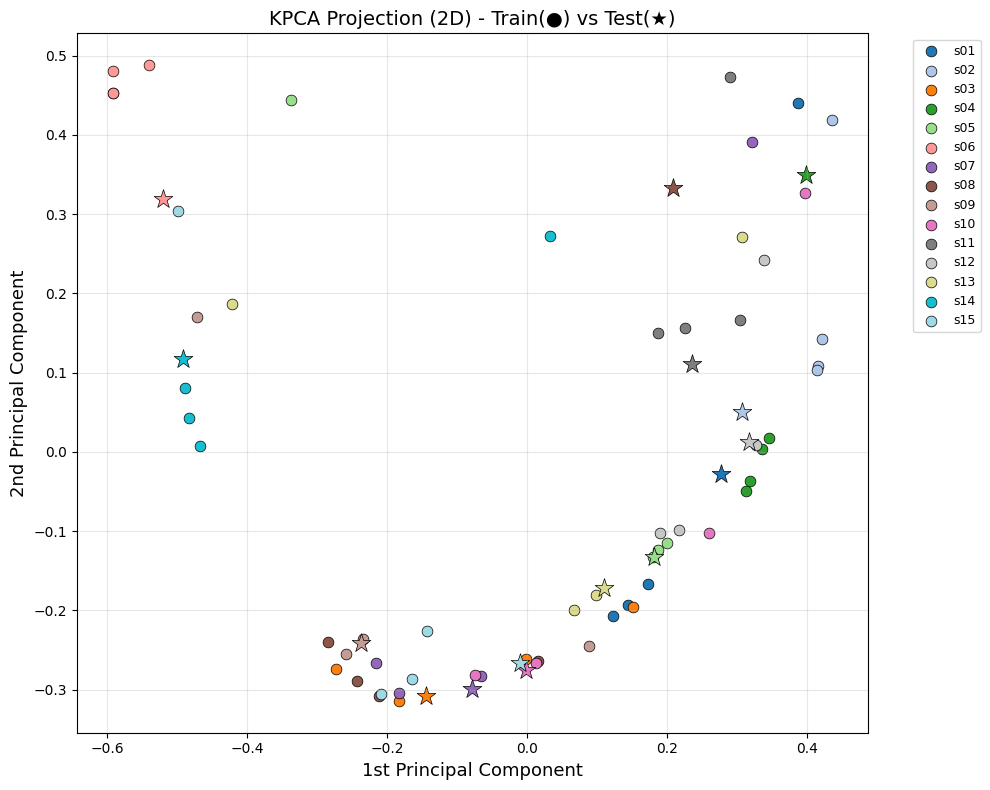

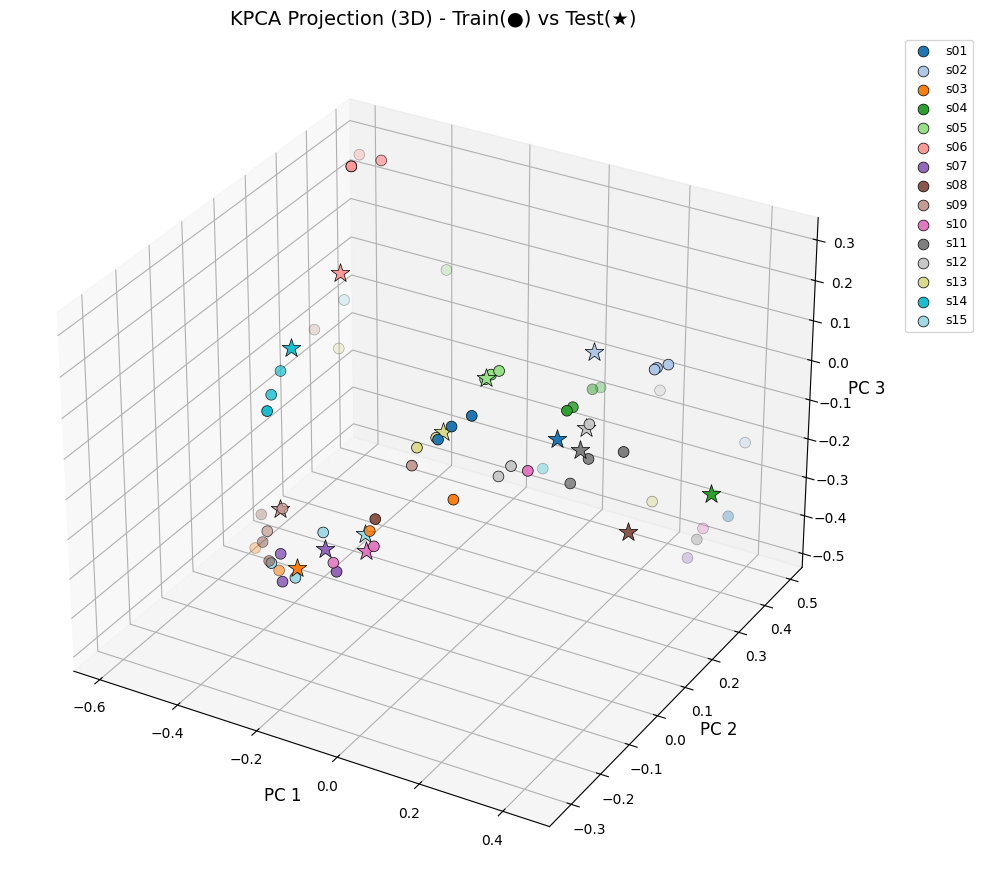

In [ ]:
# Full projection onto all components
X_train_proj = K_centered @ alphas
K_test = rbf_kernel(X_test, X_train, gamma=gamma)
N_train = X_train.shape[0]
N_test = X_test.shape[0]
one_N_test = np.ones((N_test, N_train)) / N_train
K_test_centered = K_test - one_N_test @ K_train - K_test @ one_N + one_N_test @ K_train @ one_N
X_test_proj = K_test_centered @ alphas

# First 3 components for visualization only
X_train_3d = X_train_proj[:, :3]
X_test_3d = X_test_proj[:, :3]

# Assign a color to each person
unique_labels = sorted(set(y_train))
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
label_to_color = {label: colors[i] for i, label in enumerate(unique_labels)}


# 2D Scatter Plot
plt.figure(figsize=(10, 8))

for label in unique_labels:
    mask_tr = y_train == label
    plt.scatter(X_train_3d[mask_tr, 0], X_train_3d[mask_tr, 1],
                color=label_to_color[label], label=f"{label}",
                marker='o', s=60, edgecolors='black', linewidths=0.5)
    mask_te = y_test == label
    if np.any(mask_te):
        plt.scatter(X_test_3d[mask_te, 0], X_test_3d[mask_te, 1],
                    color=label_to_color[label],
                    marker='*', s=200, edgecolors='black', linewidths=0.5)

plt.xlabel("1st Principal Component", fontsize=13)
plt.ylabel("2nd Principal Component", fontsize=13)
plt.title("KPCA Projection (2D) - Train(●) vs Test(★)", fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 3D Scatter Plot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

for label in unique_labels:
    mask_tr = y_train == label
    ax.scatter(X_train_3d[mask_tr, 0], X_train_3d[mask_tr, 1], X_train_3d[mask_tr, 2],
               color=label_to_color[label], label=f"{label}",
               marker='o', s=60, edgecolors='black', linewidths=0.5)
    mask_te = y_test == label
    if np.any(mask_te):
        ax.scatter(X_test_3d[mask_te, 0], X_test_3d[mask_te, 1], X_test_3d[mask_te, 2],
                   color=label_to_color[label],
                   marker='*', s=200, edgecolors='black', linewidths=0.5)

ax.set_xlabel("PC 1", fontsize=12)
ax.set_ylabel("PC 2", fontsize=12)
ax.set_zlabel("PC 3", fontsize=12)
ax.set_title("KPCA Projection (3D) - Train(●) vs Test(★)", fontsize=14)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

Using top 30 components
Accuracy: 86.67%  (13 / 15 correct)

Sample   True         Predicted    OK
----------------------------------------
0        s01          s01          ✓
1        s02          s02          ✓
2        s03          s03          ✓
3        s04          s01          ✗
4        s05          s05          ✓
5        s06          s06          ✓
6        s07          s07          ✓
7        s08          s01          ✗
8        s09          s09          ✓
9        s10          s10          ✓
10       s11          s11          ✓
11       s12          s12          ✓
12       s13          s13          ✓
13       s14          s14          ✓
14       s15          s15          ✓

Best k = 9, accuracy = 86.67%


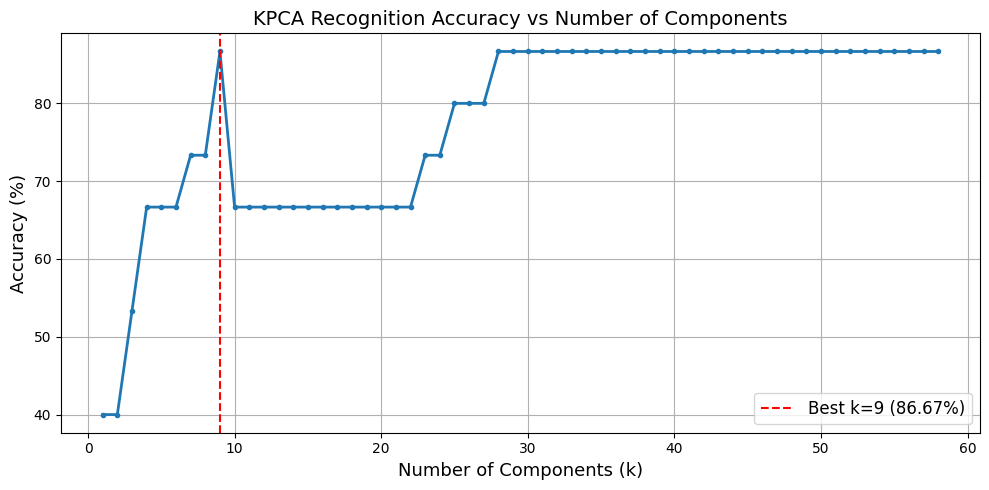

In [18]:
# ====================================================================
# 1-NN Classification with KPCA Projections
# ====================================================================

def nearest_neighbor_classify(X_train_proj, y_train, X_test_proj):
    """1-nearest-neighbour classifier using Euclidean distance (vectorized)."""
    # (n_test, n_train) distance matrix in one shot
    dists = np.linalg.norm(
        X_test_proj[:, np.newaxis, :] - X_train_proj[np.newaxis, :, :], axis=2
    )
    return y_train[np.argmin(dists, axis=1)]


# --- Single-k evaluation ---
k = 30
predictions = nearest_neighbor_classify(X_train_proj[:, :k], y_train, X_test_proj[:, :k])

accuracy = np.mean(predictions == y_test) * 100
print(f"Using top {k} components")
print(f"Accuracy: {accuracy:.2f}%  ({np.sum(predictions == y_test)} / {len(y_test)} correct)")

# --- Per-sample results ---
print(f"\n{'Sample':<8} {'True':<12} {'Predicted':<12} {'OK'}")
print("-" * 40)
for i in range(len(y_test)):
    mark = "✓" if predictions[i] == y_test[i] else "✗"
    print(f"{i:<8} {y_test[i]:<12} {predictions[i]:<12} {mark}")

# --- Sweep k: find the optimal number of components ---
max_k = X_train_proj.shape[1]

# Precompute per-component squared differences: (n_test, n_train, max_k)
# Cumulative sum means cum_dist_sq[:, :, k-1] = squared distance using first k components.
diff_sq = (X_test_proj[:, np.newaxis, :] - X_train_proj[np.newaxis, :, :]) ** 2
cum_dist_sq = np.cumsum(diff_sq, axis=2)

acc_list = [
    np.mean(y_train[np.argmin(cum_dist_sq[:, :, k - 1], axis=1)] == y_test) * 100
    for k in range(1, max_k + 1)
]

k_list = list(range(1, max_k + 1))
best_k = k_list[np.argmax(acc_list)]
best_acc = max(acc_list)
print(f"\nBest k = {best_k}, accuracy = {best_acc:.2f}%")

plt.figure(figsize=(10, 5))
plt.plot(k_list, acc_list, marker='o', markersize=3, linewidth=2)
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Best k={best_k} ({best_acc:.2f}%)')
plt.xlabel("Number of Components (k)", fontsize=13)
plt.ylabel("Accuracy (%)", fontsize=13)
plt.title("KPCA Recognition Accuracy vs Number of Components", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()